<a href="https://colab.research.google.com/github/Aziz4785/ML/blob/master/proGAN_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import kagglehub
from pathlib import Path
from PIL import Image
import os
import kagglehub
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.utils import save_image
import torchvision
from torch.cuda.amp import GradScaler
from tqdm import tqdm
from torch import autograd

In [ ]:
class config:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    Z_DIM = 512
    LAMBDA_GP = 10.0      #  WGAN-GP value
    DATASET = "faces_64x64" #"celebahq64" #"faces_64x64"
    MAX_EPOCHS_FOR_RESOLUTION =  [25, 40, 32, 31, 45]
    BATCH_SIZE=16
    SAMPLES_VISUALIZATION_SIZE = 40

first of all we download the dataset of faces:

In [ ]:

if config.DATASET == "faces_64x64":
  path = kagglehub.dataset_download(
      "ashwingupta3012/human-faces",
      force_download=True
  )
elif config.DATASET == "celebahq64":
  path = kagglehub.dataset_download("badasstechie/celebahq-resized-256x256")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'human-faces' dataset.
Dataset downloaded to: /kaggle/input/human-faces


we resize all images to 64*64

In [ ]:
def center_crop_to_square(img: Image.Image) -> Image.Image:
    w, h = img.size
    if w == h:
        return img
    if w > h:
        left = (w - h) // 2
        right = left + h
        top = 0
        bottom = h
    else:
        top = (h - w) // 2
        bottom = top + w
        left = 0
        right = w
    return img.crop((left, top, right, bottom))

In [ ]:
input_dir = path
output_dir = "/content/faces_64x64"

os.makedirs(output_dir, exist_ok=True)

count = 0

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(root, file)
            try:
                img = Image.open(img_path).convert("RGB")
                img = center_crop_to_square(img)
                img = img.resize((64, 64), Image.BICUBIC)

                save_path = os.path.join(output_dir, file)
                img.save(save_path)

                count += 1
            except:
                print("Error loading:", img_path)

print(f"Done! Processed {count} images into {output_dir}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Done! Processed 7219 images into /content/faces_64x64


different types of downsampling exist:

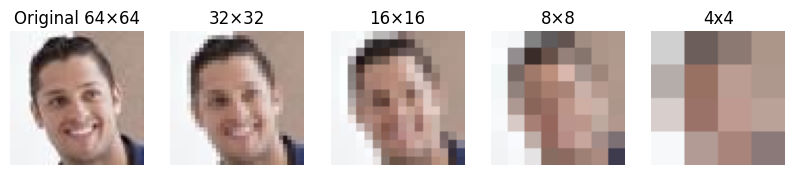

In [ ]:
dataset_dir = "/content/faces_64x64"

# pick a random image
file = random.choice([f for f in os.listdir(dataset_dir) if f.lower().endswith(("jpg","png","jpeg"))])
img_path = os.path.join(dataset_dir, file)
img = Image.open(img_path).convert("RGB")

img_32 = img.resize((32, 32), Image.BICUBIC)
img_16 = img.resize((16, 16), Image.BICUBIC)
img_8  = img.resize((8, 8), Image.BICUBIC)
img_4  = img.resize((4, 4), Image.BICUBIC)

# upscale again for visualization (so all appear 64×64 in plot) because Matplotlib does not automatically enlarge small images nicely
img_32_up = img_32.resize((64, 64), Image.NEAREST)
img_16_up = img_16.resize((64, 64), Image.NEAREST)
img_8_up  = img_8.resize((64, 64), Image.NEAREST)
img_4_up  = img_4.resize((64, 64), Image.NEAREST)

plt.figure(figsize=(10, 3))

titles = ["Original 64×64", "32×32", "16×16", "8×8", "4x4"]
images = [img, img_32_up, img_16_up, img_8_up,img_4_up]

for i, (title, image) in enumerate(zip(titles, images)):
    plt.subplot(1, 5, i+1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.show()

DIFFERENT DOWNSAMPLING TECHNIQUES

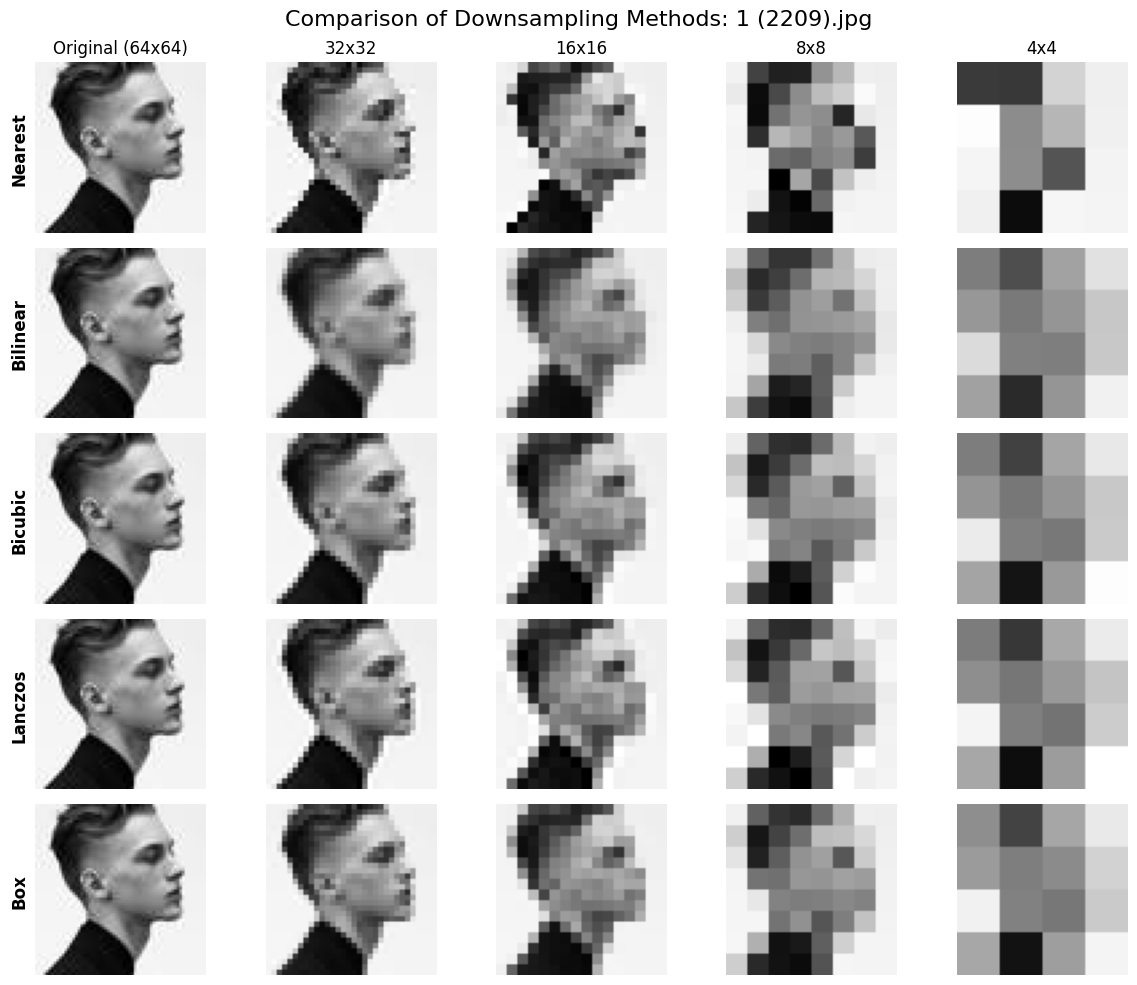

In [ ]:
dataset_dir = "/content/faces_64x64"

file = random.choice([f for f in os.listdir(dataset_dir) if f.lower().endswith(("jpg","png","jpeg"))])
img_path = os.path.join(dataset_dir, file)
img = Image.open(img_path).convert("RGB")

resolutions = [32, 16, 8, 4]

methods = {
    "Nearest": Image.NEAREST,
    "Bilinear": Image.BILINEAR,
    "Bicubic": Image.BICUBIC,
    "Lanczos": Image.LANCZOS,
    "Box": Image.BOX
}

n_rows = len(methods)
n_cols = len(resolutions) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2 * n_rows))
fig.suptitle(f"Comparison of Downsampling Methods: {file}", fontsize=16)


method_names = list(methods.keys())

for row_idx, method_name in enumerate(method_names):
    filter_type = methods[method_name]

    ax_orig = axes[row_idx, 0]
    ax_orig.imshow(img)
    ax_orig.axis("off")

    ax_orig.text(-10, 32, method_name, fontsize=12, fontweight='bold', va='center', rotation=90)

    if row_idx == 0:
        ax_orig.set_title("Original (64x64)")
-
    for col_idx, res in enumerate(resolutions):
        img_small = img.resize((res, res), filter_type)

        img_display = img_small.resize((64, 64), Image.NEAREST)

        ax = axes[row_idx, col_idx + 1]
        ax.imshow(img_display)
        ax.axis("off")

        if row_idx == 0:
            ax.set_title(f"{res}x{res}")

plt.tight_layout()
plt.show()

generator:


In [ ]:
def leaky_relu(x, alpha=0.2):
    return F.leaky_relu(x, negative_slope=alpha)

def lerp(a, b, t):
    return a + (b - a) * t

def cset(cur_lambda, new_cond, new_lambda):
    return lambda: new_lambda() if new_cond else cur_lambda()

def upscale2d(x, factor=2):
    if factor == 1:
        return x
    return F.interpolate(x, scale_factor=factor, mode='nearest')

class PixelNorm(nn.Module):
    def __init__(self, epsilon=1e-8):
        super().__init__()
        self.eps = epsilon

    def forward(self, x):
        return x * torch.rsqrt(torch.mean(x ** 2, dim=1, keepdim=True) + self.eps)

def get_weight(shape, gain=np.sqrt(2), fan_in=None):
    if fan_in is None:
        fan_in = np.prod(shape[:-1])
    std = gain / np.sqrt(fan_in)  # He init

    wscale = torch.tensor(np.float32(std))
    weight = torch.randn(shape)
    return weight * wscale


def dense(x, fmaps, gain=np.sqrt(2)):
    if len(x.shape) > 2:
        x = x.reshape(x.shape[0], -1)  # Flatten while keeping batch dimension

    w = get_weight([x.shape[1], fmaps], gain=gain)
    w = w.to(x.dtype).to(x.device)

    return torch.matmul(x, w)



class EqualizedLinear(nn.Module):
    def __init__(self, in_features, out_features, gain=np.sqrt(2)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Weight: N(0,1) then scaled at runtime
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

        fan_in = in_features
        he_std = gain / math.sqrt(fan_in)

        self.w_mul = he_std

    def forward(self, x):
        # We just flatten everything but batch.
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        w = self.weight * self.w_mul  # [out_features, in_features]
        return F.linear(x, w, self.bias)  # [N, out_features]


class EqualizedConv2d(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size, stride=1, padding=0,
                 gain=np.sqrt(2)):
        super().__init__()
        self.stride = stride
        self.padding = padding

        if isinstance(kernel_size, int):
            k = kernel_size
        else:
            k = kernel_size[0]

        self.weight = nn.Parameter(
            torch.randn(out_channels, in_channels, k, k)
        )
        self.bias = nn.Parameter(torch.zeros(out_channels))

        fan_in = in_channels * k * k
        he_std = gain / math.sqrt(fan_in)

        self.w_mul = he_std

    def forward(self, x):
        w = self.weight * self.w_mul
        return F.conv2d(x, w, self.bias, stride=self.stride, padding=self.padding)



class GBlockFirst(nn.Module):
    def __init__(self, in_features, out_channels):
        super().__init__()

        self.pixel_norm = PixelNorm()

        self.fc = EqualizedLinear(
            in_features,
            out_channels * 4 * 4,
            gain=np.sqrt(2) / 4,
        )

        # 3x3 conv
        self.conv = EqualizedConv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            gain=np.sqrt(2),
        )


    def forward(self, x, normalize_latents=True):
        if normalize_latents:
            x = self.pixel_norm(x)

        x = self.fc(x)

        N = x.shape[0]
        out_ch = x.shape[1] // (4 * 4)
        x = x.view(N, out_ch, 4, 4)

        x = leaky_relu(x)
        x = self.pixel_norm(x)

        x = self.conv(x)
        x = leaky_relu(x)
        x = self.pixel_norm(x)

        return x  # [N, out_ch, 4, 4]

class GBlockUpscale(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.pixel_norm = PixelNorm()

        # First 3x3 conv after upscaling
        self.conv0 = EqualizedConv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            padding=1,
            gain=np.sqrt(2),
        )

        # Second 3x3 conv
        self.conv1 = EqualizedConv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            padding=1,
            gain=np.sqrt(2),
        )

    def forward(self, x):
        x = upscale2d(x, factor=2)
        x = self.conv0(x)

        x = leaky_relu(x)
        x = self.pixel_norm(x)

        x = self.conv1(x)
        x = leaky_relu(x)
        x = self.pixel_norm(x)

        return x



class Generator(nn.Module):

    def __init__(
        self,
        num_channels=1,
        max_resolution=64,
        latent_size=None,
    ):
        super().__init__()

        self.num_channels = num_channels
        self.max_resolution = max_resolution
        self.max_resolution_log2 = int(np.log2(max_resolution))

        # Default latent size
        if latent_size is None:
            latent_size = 512
        self.latent_size = latent_size

        # Channels per resolution block: res in [2..resolution_log2] #number of features (=number of channels)
        self.channels = {
            2: 512,  # 4x4
            3: 512,  # 8x8
            4: 512,  # 16x16
            5: 512,  # 32x32
            6: 256,  # 64x64
            7: 128,  # 128x128
            8: 64,   # 256x256
            9: 32,   # 512x512
            10: 16,  # 1024x1024
        }

        self.blocks = nn.ModuleDict()
        self.rgb_layers = nn.ModuleDict()

        in_features_first = self.latent_size

        for res in range(2, self.max_resolution_log2 + 1):
            if res == 2:
                # First block (4x4)
                self.blocks[str(res)] = GBlockFirst(
                    in_features=in_features_first,
                    out_channels=self.channels[res],
                )
            else:
                # Higher-res blocks
                self.blocks[str(res)] = GBlockUpscale(
                    in_channels=self.channels[res - 1],
                    out_channels=self.channels[res],
                )

            # rgb_layers for this resolution
            self.rgb_layers[str(res)] = EqualizedConv2d(
                in_channels=self.channels[res],
                out_channels=self.num_channels,
                kernel_size=1,
                padding=0,
                gain=1.0,
            )

    def forward(self, x, alpha, resolution): #reoslution can be 4, 8, 16, 32, 64 etc..
        log2_res = int(np.log2(resolution))
        # 4x4 block
        x = self.blocks["2"](x)

        if log2_res == 2:
            return self.rgb_layers["2"](x)

        for res in range(3, log2_res):
            x = self.blocks[str(res)](x)

        # Previous resolution image (e.g. for 16x16 stage, this is 8x8).
        prev_img = self.rgb_layers[str(log2_res - 1)](x)

        x = self.blocks[str(log2_res)](x)
        new_img = self.rgb_layers[str(log2_res)](x)

        if alpha >= 1.0:
            return new_img

        prev_img_upsampled = upscale2d(prev_img, factor=2)

        out = alpha * new_img + (1.0 - alpha) * prev_img_upsampled
        return out





discriminator:

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


class WSConv2d(nn.Module):
    """
    This is the wt scaling conv layer. Initialize with N(0, scale). Then
    it will multiply the scale for every forward pass
    """
    def __init__(self, inCh, outCh, kernelSize, stride, padding, gain=np.sqrt(2)):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=inCh, out_channels=outCh,
                              kernel_size=kernelSize, stride=stride, padding=padding)

        self.bias = self.conv.bias
        self.conv.bias = None

        convShape = list(self.conv.weight.shape)
        fanIn = np.prod(convShape[1:])
        self.wtScale = gain / np.sqrt(fanIn)

        nn.init.normal_(self.conv.weight)
        nn.init.constant_(self.bias, val=0)

    def forward(self, x):
        return self.conv(x) * self.wtScale + self.bias.view(1, self.bias.shape[0], 1, 1)


class WSLinear(nn.Module):
    """
    Linear/Dense with Weight Scaling (Equalized Learning Rate).
    """
    def __init__(self, in_features, out_features, bias=True, gain=np.sqrt(2)):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)

        # Initialize weights with N(0, 1)
        nn.init.normal_(self.linear.weight)
        if bias:
            nn.init.zeros_(self.linear.bias)

        # Calculate scale factor
        fan_in = self.linear.weight.shape[1]
        self.scale = gain / np.sqrt(fan_in)

    def forward(self, x):
        # equalized LR: scale weights at the forward pass
        return self.linear(x) * self.scale


class MinibatchStdDev(nn.Module):
    def __init__(self, group_size=4):
        super().__init__()
        self.group_size = group_size

    def forward(self, x):
        """
        x: Tensor of shape [N, C, H, W]
        """
        N, C, H, W = x.shape
        group_size = min(self.group_size, N)
        if N % group_size != 0:
            group_size = N
        y = x.view(group_size, -1, C, H, W)
        y = y.float()  # Cast to FP32
        y = y - y.mean(dim=0, keepdim=True)      # [G, M, C, H, W]
        y = y.pow(2).mean(dim=0)                 # [M, C, H, W]
        y = torch.sqrt(y + 1e-8)                 # [M, C, H, W]
        y = y.mean(dim=[1, 2, 3], keepdim=True)  # [M, 1, 1, 1]
        y = y.to(x.dtype)
        y = y.repeat(group_size, 1, H, W)        # [N, 1, H, W]
        return torch.cat([x, y], dim=1)          # [N, C+1, H, W]



class DiscriminatorBlock(nn.Module):
    """
    General Conv Block for resolutions >= 8x8.
    Conv 3x3 -> Act -> Conv 3x3 -> Act -> Downscale
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Conv0
        self.conv0 = WSConv2d(in_channels, in_channels, kernelSize=3, stride=1, padding=1)
        # Conv1
        self.conv1 = WSConv2d(in_channels, out_channels, kernelSize=3, stride=1, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x = self.act(self.conv0(x))
        x = self.act(self.conv1(x))
        x = F.avg_pool2d(x, 2)  # downscale by 2
        return x


class DiscriminatorLastBlock(nn.Module):
    """
    Final Block for resolution 4x4.
    MBStdDev -> Conv 3x3 -> Dense -> Dense
    """
    def __init__(self, in_channels, out_channels_dense, label_size=0, mbstd_group_size=4):
        super().__init__()
        self.mbstd = MinibatchStdDev(group_size=mbstd_group_size)

        self.conv = WSConv2d(in_channels + 1, in_channels, kernelSize=3, stride=1, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)

        self.dense0 = WSLinear(in_channels * 4 * 4, out_channels_dense)


        self.dense1 = WSLinear(out_channels_dense, 1 + label_size, gain=1.0)
        self.label_size = label_size

    def forward(self, x):
        x = self.mbstd(x)
        x = self.act(self.conv(x))

        x = x.view(x.shape[0], -1)
        x = self.act(self.dense0(x))
        x = self.dense1(x)

        scores = x[:, :1]
        labels = x[:, 1:] if self.label_size > 0 else None
        return scores


# --------------------------------------------------------------------------------
# Main Discriminator Class
# --------------------------------------------------------------------------------

class Discriminator(nn.Module):
    def __init__(self,
                 num_channels=3,
                 max_resolution=1024,
                 label_size=0,
                 fmap_base=8192,
                 fmap_decay=1.0,
                 fmap_max=512,
                 mbstd_group_size=4):
        super().__init__()

        self.num_channels = num_channels
        self.max_resolution = max_resolution
        self.max_resolution_log2 = int(np.log2(max_resolution))
        self.label_size = label_size

        # Same channel config as your Generator
        self.channels = {
            2: 512,  # 4x4
            3: 512,  # 8x8
            4: 512,  # 16x16
            5: 512,  # 32x32
            6: 256,  # 64x64
            7: 128,  # 128x128
            8: 64,   # 256x256
            9: 32,   # 512x512
            10: 16,  # 1024x1024
        }

        # blocks[res] processes feature maps at resolution 2^res
        self.blocks = nn.ModuleDict()
        self.from_rgb = nn.ModuleDict()
        self.act = nn.LeakyReLU(0.2, inplace=True)

        # FromRGB for all resolutions: num_channels -> channels[res]
        for res in range(2, self.max_resolution_log2 + 1):
            self.from_rgb[f'{res}'] = WSConv2d(
                num_channels,
                self.channels[res],
                kernelSize=1,
                stride=1,
                padding=0
            )

        # Last 4x4 block (res=2)
        self.blocks['2'] = DiscriminatorLastBlock(
            in_channels=self.channels[2],
            out_channels_dense=self.channels[2],
            label_size=label_size,
            mbstd_group_size=mbstd_group_size
        )


        for res in range(3, self.max_resolution_log2 + 1):
            self.blocks[f'{res}'] = DiscriminatorBlock(
                in_channels=self.channels[res],
                out_channels=self.channels[res - 1]
            )

    def forward(self, x, alpha, resolution):

        log2_res = int(np.log2(resolution))
        assert 2 <= log2_res <= self.max_resolution_log2, "Invalid resolution"

        # --- 4x4 stage (no fade-in) ---
        if log2_res == 2:
            x = self.act(self.from_rgb['2'](x))
            scores = self.blocks['2'](x)
            return scores

        y = self.act(self.from_rgb[f'{log2_res}'](x))
        y = self.blocks[f'{log2_res}'](y)   # now at resolution log2_res-1

        if alpha < 1.0:
            # Skip path: downsample image then use lower-res FromRGB
            x_down = F.avg_pool2d(x, 2)
            skip = self.act(self.from_rgb[f'{log2_res - 1}'](x_down))
            # Blend features
            x = alpha * y + (1.0 - alpha) * skip
        else:
            x = y

        for res in range(log2_res - 1, 2, -1):
            x = self.blocks[f'{res}'](x)

        scores = self.blocks['2'](x)
        return scores


training loop

In [ ]:


def gradient_penalty(D, real, fake, alpha, step, device):
    """
    WGAN-GP gradient penalty on the interpolated samples.
    D: the *wrapped* discriminator (returns scores)
    """
    batch_size = real.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device) #like the original code

    interpolated_images = epsilon * real + (1 - epsilon) * fake
    interpolated_images.requires_grad_(True)

    disc_scores_of_interpolated = D(interpolated_images, alpha, step)

    grads = autograd.grad(
        inputs=interpolated_images,
        outputs=disc_scores_of_interpolated,
        grad_outputs=torch.ones_like(disc_scores_of_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    grads = grads.view(batch_size, -1) #flatten the gradients
    gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean()
    return gp

import torch.nn.functional as F

def downscale_to_resolution(x, res: int):
    if x.shape[-1] == res:
        return x
    return F.interpolate(x, size=(res, res), mode="bilinear", align_corners=False)

def resolution_to_step(resolution: int) -> int:
    return int(math.log2(resolution) - 2)

def get_max_epochs_for_resolution(res):
    # example: more epochs for higher resolutions
    return config.MAX_EPOCHS_FOR_RESOLUTION[resolution_to_step(res)]

UPSAMPLE_SAVE_SIZE = 64

def train_progan(
    G,
    D,
    resolutions,
    data_loader,
    get_max_epochs_for_resolution,
    opt_G,
    opt_D,
    scaler_G=None,
    scaler_D=None,
    writer=None,
    fixed_noise=None,
    start_step: int = 0,
    start_alpha: float = 0.0,
    drift: float = 0.001,
):
    print(f"train_progan(G,D,resolutions = {resolutions}, start_step = {start_step}, start_alpha = {start_alpha})")

    device = config.DEVICE
    tensorboard_step = 0
    step_global = start_step
    start_res=4
    alpha = start_alpha

    for res in resolutions:
        print("we process res ",res)

        if res < start_res:
            continue  # skip already-trained resolutions

        max_epochs = int(get_max_epochs_for_resolution(res))
        fade_epochs = max_epochs // 2
        stable_epochs = max_epochs - fade_epochs

        # total number of batches *during fade*
        total_fade_batches = fade_epochs * len(data_loader) if fade_epochs > 0 else 1

        print(f"Training at resolution {res}x{res},  "
              f"we train for {max_epochs} epochs (fade={fade_epochs} epochs, stable={stable_epochs} epochs)")

        alpha = start_alpha if res == start_res else 0.0

        for epoch in range(max_epochs):
            loop = tqdm(data_loader, leave=False)
            for batch_idx, real in enumerate(loop):
                #print("batch index n° ",batch_idx)
                real = real.to(device)
                cur_batch_size = real.size(0)

                # Downscale real images to current resolution
                real_res = downscale_to_resolution(real, res)

                # ---------------------------
                # 1. Train Discriminator
                # ---------------------------
                z = torch.randn(cur_batch_size, config.Z_DIM, 1, 1, device=device)

                use_amp_D = scaler_D is not None
                context_D = torch.cuda.amp.autocast() if use_amp_D else torch.no_grad()  # placeholder

                #print(f"we generate fake images using G(z,alpha : {alpha}, res :{res}) and shape of z is : {z.shape} ")
                fake = G(z, alpha, res)

                D_real = D(real_res, alpha, res)
                D_fake = D(fake.detach(), alpha, res)

                gp = gradient_penalty(D, real_res, fake.detach(), alpha, res, device=device)

                loss_D = (
                    -(torch.mean(D_real) - torch.mean(D_fake))
                    + config.LAMBDA_GP * gp
                    + drift * torch.mean(D_real ** 2)
                )

                opt_D.zero_grad(set_to_none=True)

                loss_D.backward()
                opt_D.step()

                # ---------------------------
                # 2. Train Generator
                # ---------------------------
                z = torch.randn(cur_batch_size, config.Z_DIM, 1, 1, device=device)

                use_amp_G = scaler_G is not None
                context_G = torch.cuda.amp.autocast() if use_amp_G else context_D  # reuse dummy/no-op

                with context_G:
                    fake = G(z, alpha, res)
                    D_fake_for_G = D(fake, alpha, res)
                    loss_G = -torch.mean(D_fake_for_G)

                opt_G.zero_grad(set_to_none=True)
                if use_amp_G:
                    scaler_G.scale(loss_G).backward()
                    scaler_G.step(opt_G)
                    scaler_G.update()
                else:
                    loss_G.backward()
                    opt_G.step()

                # ---------------------------
                # 3. Update alpha (fade-in)
                # ---------------------------
                if epoch < fade_epochs and fade_epochs > 0:
                    alpha += cur_batch_size / (total_fade_batches * cur_batch_size)
                    alpha = min(alpha, 1.0)
                else:
                    alpha = 1.0

                loop.set_postfix(
                    res=res,
                    epoch=epoch,
                    alpha=float(f"{alpha:.3f}"),
                    loss_D=float(loss_D.item()),
                    loss_G=float(loss_G.item()),
                    gp=float(gp.item()),
                )

                if writer is not None and fixed_noise is not None and tensorboard_step % 1000 == 0:
                    with torch.no_grad():
                        # generate fixed samples at current resolution
                        fixed_fake = G(fixed_noise.to(device), alpha, res)
                        fixed_fake = (fixed_fake * 0.5) + 0.5  # if you use [-1,1] -> [0,1]
                        # --- only for visualization: upsample to a nicer size ---
                        vis_fake = F.interpolate(
                            fixed_fake,
                            size=(UPSAMPLE_SAVE_SIZE, UPSAMPLE_SAVE_SIZE),
                            mode="nearest"  # or "bilinear" with align_corners=False if you prefer smooth
                        )

                    os.makedirs(f"samples/{res}x{res}", exist_ok=True)
                    save_image(
                        vis_fake[:config.SAMPLES_VISUALIZATION_SIZE],
                        f"samples/{res}x{res}/step_{step_global:03d}_epoch_{epoch:03d}_iter_{tensorboard_step:06d}.png",
                        nrow=8,
                        normalize=True,
                    )

                    # grid = torchvision.utils.make_grid(
                    #     downscale_to_resolution(real[:config.SAMPLES_VISUALIZATION_SIZE], res), normalize=True
                    # )
                    # writer.add_image(f"real_{res}", grid, global_step=tensorboard_step)

                    # grid_fake = torchvision.utils.make_grid(
                    #     downscale_to_resolution(fixed_fake[:config.SAMPLES_VISUALIZATION_SIZE], res), normalize=True
                    # )
                    # writer.add_image(f"fake_{res}", grid_fake, global_step=tensorboard_step)

                    # writer.add_scalar(f"loss_D/{res}", loss_D.item(), tensorboard_step)
                    # writer.add_scalar(f"loss_G/{res}", loss_G.item(), tensorboard_step)
                    # writer.add_scalar(f"alpha/{res}", alpha, tensorboard_step)

                tensorboard_step += 1

            print(f"Finished resolution {res}x{res}, epoch {epoch+1}/{max_epochs}, alpha={alpha:.3f}")

        step_global += 1

    print("Training complete.")
    return

In [ ]:

output_dir = "/content/faces_64x64"

class FlatImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        exts = (".jpg", ".jpeg", ".png")
        self.image_paths = [
            os.path.join(root, f)
            for f in os.listdir(root)
            if f.lower().endswith(exts)
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img  # no labels for GANs

# --- Transforms (match GAN input: [-1, 1]) ---
transform = T.Compose([
    T.ToTensor(),                       # [0,1]
    T.Normalize([0.5, 0.5, 0.5],
                [0.5, 0.5, 0.5])        # -> [-1,1]
])

dataset = FlatImageDataset(output_dir, transform=transform)

data_loader = DataLoader(
    dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:


G = Generator(num_channels=3, max_resolution=64, latent_size=config.Z_DIM).to(config.DEVICE)
D = Discriminator(num_channels=3, max_resolution=64).to(config.DEVICE)

opt_G = torch.optim.Adam(G.parameters(), lr=1e-3, betas=(0.0, 0.99))
opt_D = torch.optim.Adam(D.parameters(), lr=1e-3, betas=(0.0, 0.99))


scaler_G = GradScaler()
scaler_D = GradScaler()


resolutions = [4, 8, 16, 32, 64]

fixed_noise = torch.randn(64, config.Z_DIM, 1, 1, device=config.DEVICE)


from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(log_dir="./logs_progan")


train_progan(
    G=G,
    D=D,
    resolutions=resolutions,
    data_loader=data_loader,
    get_max_epochs_for_resolution=get_max_epochs_for_resolution,
    opt_G=opt_G,
    opt_D=opt_D,
    scaler_G=scaler_G,
    scaler_D=scaler_D,
    writer=writer,
    fixed_noise=fixed_noise,
    start_step=0,
    start_alpha=0.0,
    drift=0.001,
)

/tmp/ipython-input-40291110.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G = GradScaler()
/tmp/ipython-input-40291110.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D = GradScaler()


train_progan(G,D,resolutions = [4, 8, 16, 32, 64], start_step = 0, start_alpha = 0.0)
we process res  4
Training at resolution 4x4,  we train for 25 epochs (fade=12 epochs, stable=13 epochs)


  0%|          | 0/452 [00:00<?, ?it/s]/tmp/ipython-input-1980624332.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  context_D = torch.cuda.amp.autocast() if use_amp_D else torch.no_grad()  # placeholder
/tmp/ipython-input-1980624332.py:166: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  context_G = torch.cuda.amp.autocast() if use_amp_G else context_D  # reuse dummy/no-op


Finished resolution 4x4, epoch 1/25, alpha=0.083


Finished resolution 4x4, epoch 2/25, alpha=0.167


...

Finished resolution 64x64, epoch 13/45, alpha=0.591


Finished resolution 64x64, epoch 14/45, alpha=0.636


Finished resolution 64x64, epoch 15/45, alpha=0.682


Finished resolution 64x64, epoch 16/45, alpha=0.727


KeyboardInterrupt: 